# Edward Moswane Project_02: Preparing Stock Data for Machine Learning

## Introduction
The second project builds on Project_01 by cleaning the historical stock-price data, investigating unusual observations, creating useful features, combining the datasets, and preparing a final dataset for future modeling for possibly project03.


# Significant Dataset Consistency Check
The first project,Project_01 used the historical price dataset through August 24, 2018 and reported 1,598,956 original price records. Therefore, with 1,598,955 complete records after removing one incomplete observation. I have applied that same Project_01 date boundary so that Project_02 continues from the same data used previously.

In [ ]:
# Significant library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler

In [ ]:
# Loading the datasets provided.
stocks = pd.read_csv('/content/historical_stocks.csv')
stock_prices = pd.read_csv('/content/historical_stock_prices.csv')

print('Historical Stocks Dataset:', stocks.shape)
print('Historical Stock Prices Dataset:', stock_prices.shape)

Historical Stocks Dataset: (6460, 5)
Historical Stock Prices Dataset: (159037, 8)


The purpose for this line below. Is to make sure Project_02 stays consistent with the Project 1 time period and doesn't accidentally introduce data from a later period.

In [ ]:
# Converting date and inspect the raw date range
stock_prices['date'] = pd.to_datetime(stock_prices['date'], errors='coerce')

print('Raw minimum date:', stock_prices['date'].min())
print('Raw maximum date:', stock_prices['date'].max())

# Project 1 used data through August 24, 2018.
PROJECT1_END_DATE = pd.Timestamp('2018-08-24')
stock_prices = stock_prices[stock_prices['date'] <= PROJECT1_END_DATE].copy()

print('Rows after applying the Project 1 date boundary:', len(stock_prices))
print('Project 1-period minimum date:', stock_prices['date'].min())
print('Project 1-period maximum date:', stock_prices['date'].max())

Raw minimum date: 1973-05-03 00:00:00
Raw maximum date: 2018-08-24 00:00:00
Rows after applying the Project 1 date boundary: 159036
Project 1-period minimum date: 1973-05-03 00:00:00
Project 1-period maximum date: 2018-08-24 00:00:00


In [ ]:
# Initial missing-value check
print('Missing values in historical_stocks:')
display(stocks.isnull().sum())

print('Missing values in historical_stock_prices:')
display(stock_prices.isnull().sum())

Missing values in historical_stocks:


,0
ticker,0
exchange,0
name,0
sector,1440
industry,1440


Missing values in historical_stock_prices:


,0
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0


In [ ]:
# Sorting by ticker and date
stock_prices = stock_prices.sort_values(['ticker', 'date']).reset_index(drop=True)

print('Date data type:', stock_prices['date'].dtype)
display(stock_prices.head())

Date data type: datetime64[ns]


,ticker,open,close,adj_close,low,high,volume,date
0,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400.0,1980-12-12
1,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200.0,1980-12-15
2,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000.0,1980-12-16
3,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400.0,1980-12-17
4,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400.0,1980-12-18


## Part 1 — Clean and Prepare the Data

From Project_01, I have identified one incomplete price record and one accidental symbol record in the historical stock information dataset. The incomplete price record is removed because important fields are missing. The accidental symbol record is removed from the histircal stock information dataset.

In [ ]:
# Removing incomplete price records that where identified in Project_01
required_price_columns = ['date', 'adj_close', 'low', 'high', 'volume']

rows_before_cleaning = len(stock_prices)
stock_prices = stock_prices.dropna(subset=required_price_columns).copy()
rows_after_cleaning = len(stock_prices)

print('Rows before cleaning:', rows_before_cleaning)
print('Rows after cleaning:', rows_after_cleaning)
print('Rows removed:', rows_before_cleaning - rows_after_cleaning)

Rows before cleaning: 159036
Rows after cleaning: 159036
Rows removed: 0


In [ ]:
# Removing the accidental Symbol record if present
print('Symbol records in price data:', (stock_prices['ticker'] == 'Symbol').sum())
print('Symbol records in stock data:', (stocks['ticker'] == 'Symbol').sum())

stock_prices = stock_prices[stock_prices['ticker'] != 'Symbol'].copy()
stocks = stocks[stocks['ticker'] != 'Symbol'].copy()

print('Remaining Symbol records in price data:', (stock_prices['ticker'] == 'Symbol').sum())
print('Remaining Symbol records in stock data:', (stocks['ticker'] == 'Symbol').sum())

Symbol records in price data: 0
Symbol records in stock data: 1
Remaining Symbol records in price data: 0
Remaining Symbol records in stock data: 0


In [ ]:
# Checking duplicates
print('Duplicate rows in stocks:', stocks.duplicated().sum())
print('Duplicate rows in stock prices:', stock_prices.duplicated().sum())
print('Duplicate ticker + date records:', stock_prices.duplicated(subset=['ticker', 'date']).sum())

Duplicate rows in stocks: 0
Duplicate rows in stock prices: 0
Duplicate ticker + date records: 0


### Investigating Unusual Observations

Project_01 identified unusually large values in close and adj_close. These observations were reviewed in Project 2 rather than automatically assuming they were errors. The current data also contains extreme price movements that can produce unrealistic daily-return values.

A robust IQR-based check is applied below for close and volume. Adding IQR check is applied to daily returns after sorting by ticker and date. Extreme observations are removed when they meet the defined robust outlier criteria. This reduces the effect of extreme observations on engineered return and volatility features while avoiding removal of all naturally high or low stock prices.


In [ ]:
# Robust IQR-based outlier detection for close price, volume, and daily return

# Preserving original row order so engineered returns are not calculated during observation
stock_prices = stock_prices.reset_index(drop=True).copy()
stock_prices['_original_row'] = np.arange(len(stock_prices))

# Close-price IQR bounds within each ticker
close_q1 = stock_prices.groupby('ticker')['close'].transform('quantile', 0.25)
close_q3 = stock_prices.groupby('ticker')['close'].transform('quantile', 0.75)
close_iqr = close_q3 - close_q1

close_lower = close_q1 - 3 * close_iqr
close_upper = close_q3 + 3 * close_iqr

close_outlier = (
    (stock_prices['close'] < close_lower) |
    (stock_prices['close'] > close_upper))

# Volume IQR bounds within each ticker
volume_q1 = stock_prices.groupby('ticker')['volume'].transform('quantile', 0.25)
volume_q3 = stock_prices.groupby('ticker')['volume'].transform('quantile', 0.75)
volume_iqr = volume_q3 - volume_q1

volume_lower = volume_q1 - 3 * volume_iqr
volume_upper = volume_q3 + 3 * volume_iqr

volume_outlier = (
    (stock_prices['volume'] < volume_lower) |
    (stock_prices['volume'] > volume_upper))

# Temporary daily return for identifying extreme return observations
temp_daily_return = stock_prices.groupby('ticker')['close'].pct_change()

return_q1 = temp_daily_return.groupby(
    stock_prices['ticker']).transform('quantile', 0.25)

return_q3 = temp_daily_return.groupby(
    stock_prices['ticker']).transform('quantile', 0.75)

return_iqr = return_q3 - return_q1

return_lower = return_q1 - 3 * return_iqr
return_upper = return_q3 + 3 * return_iqr

return_outlier = (
    (temp_daily_return < return_lower) |
    (temp_daily_return > return_upper))

# Removing records identified as extreme by the robust rules.
# Returning outliers are included because they can strongly distort
# Rolling volatility and other engineered features.
combined_outlier = ((close_outlier & volume_outlier) |return_outlier)

print("Potential close-price outliers:", int(close_outlier.sum()))
print("Potential volume outliers:", int(volume_outlier.sum()))
print("Extreme daily-return observations:", int(return_outlier.sum()))
print("Total observations selected for removal:", int(combined_outlier.sum()))

print("\nLargest observations selected for removal:")
display(stock_prices.loc[combined_outlier,['ticker', 'date', 'close', 'volume']].assign(
        temp_daily_return=temp_daily_return.loc[combined_outlier].values
    ).sort_values('temp_daily_return', ascending=False).head(20))


Potential close-price outliers: 1942
Potential volume outliers: 4497
Extreme daily-return observations: 2567
Total observations selected for removal: 2642

Largest observations selected for removal:


,ticker,date,close,volume,temp_daily_return
157591,VTNR,2004-03-26,72.00000,3600.0,7.571429
157568,VTNR,2002-11-21,9.00000,400.0,6.500000
53476,CLWT,2003-07-09,12.51905,40900.0,2.593989
52877,CLWT,2000-03-09,16.62088,770300.0,2.473683
157468,VTNR,2000-01-13,102.00000,2700.0,2.400000
157384,VTNR,1997-05-22,120.00000,1200.0,2.333333
157476,VTNR,2000-01-27,258.00000,5200.0,2.307692
53623,CLWT,2004-03-03,28.60000,1009400.0,2.000001
157381,VTNR,1997-04-17,54.00000,100.0,2.000000
157584,VTNR,2003-11-06,30.00000,300.0,1.941177


In [ ]:
# Remove observations identified as extreme in both close price and volume
rows_before_outlier_removal = len(stock_prices)

stock_prices = stock_prices.loc[~combined_outlier].copy().reset_index(drop=True)

rows_after_outlier_removal = len(stock_prices)

print("Rows before outlier removal:", rows_before_outlier_removal)
print("Rows after outlier removal:", rows_after_outlier_removal)
print("Rows removed:", rows_before_outlier_removal - rows_after_outlier_removal)


Rows before outlier removal: 159036
Rows after outlier removal: 156394
Rows removed: 2642


### Decision on Unusual Observations

The unusual observations were investigated using conservative 3 × IQR checks within each ticker for closing price, trading volume, and daily return. This ticker-level approach helps avoid treating normal differences between stocks as errors.

Records identified as extreme by the defined outlier rules were removed because they could distort daily returns and rolling volatility. After removal, engineered returns were calculated only when a valid previous observation remained, so returns were not created across rows removed during cleaning. The remaining historical observations were retained.


In [ ]:
# Reviewing the highest closing-price observations
highest_close = stock_prices.nlargest(10, 'close')[
    ['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']]
display(highest_close)

# Reviewing the highest adjusted closing-price observations
highest_adj_close = stock_prices.nlargest(10, 'adj_close')[
    ['ticker', 'date', 'close', 'adj_close', 'volume']]
display(highest_adj_close)

,ticker,date,open,high,low,close,adj_close,volume
150164,VIAV,2000-03-06,643.913513,686.291260,643.913513,666.808899,666.808899,4242700.0
150165,VIAV,2000-03-07,686.006836,698.165405,617.605225,653.868042,653.868042,5100600.0
150161,VIAV,2000-03-01,624.573364,643.060303,613.765625,639.078491,639.078491,3724400.0
150163,VIAV,2000-03-03,647.610901,648.179749,631.399292,637.087585,637.087585,2844600.0
150168,VIAV,2000-03-10,617.463013,648.464172,591.581360,627.986328,627.986328,4660100.0
150162,VIAV,2000-03-02,643.913513,650.099426,605.802063,621.160400,621.160400,3609500.0
150166,VIAV,2000-03-08,667.804321,668.941956,602.957886,621.160400,621.160400,7499100.0
150167,VIAV,2000-03-09,610.921509,626.564270,596.416382,620.022766,620.022766,4159600.0
150258,VIAV,2000-07-26,593.856628,639.362915,587.030701,618.600708,618.600708,21002100.0
150255,VIAV,2000-07-21,576.293945,626.279846,573.947693,613.481201,613.481201,14247500.0


,ticker,date,close,adj_close,volume
150164,VIAV,2000-03-06,666.808899,666.808899,4242700.0
150165,VIAV,2000-03-07,653.868042,653.868042,5100600.0
150161,VIAV,2000-03-01,639.078491,639.078491,3724400.0
150163,VIAV,2000-03-03,637.087585,637.087585,2844600.0
150168,VIAV,2000-03-10,627.986328,627.986328,4660100.0
150162,VIAV,2000-03-02,621.160400,621.160400,3609500.0
150166,VIAV,2000-03-08,621.160400,621.160400,7499100.0
150167,VIAV,2000-03-09,620.022766,620.022766,4159600.0
150258,VIAV,2000-07-26,618.600708,618.600708,21002100.0
150255,VIAV,2000-07-21,613.481201,613.481201,14247500.0


### Decision on Unusual Values

Unusual values were not removed simply because they were large. They were investigated using ticker-level 3 × IQR rules for close price, volume, and daily return. Records meeting the defined outlier criteria were removed because they could create unrealistic return and volatility values. Returns were then recalculated after cleaning without crossing gaps created by removed observations.


# Part 2 — Create Useful Features


The original row number is used to identify whether a prior observation was removed during cleaning. This prevents artificial returns across removed observations.

In [ ]:
# Creating engineered features after data cleaning
stock_prices['previous_original_row'] = (
    stock_prices.groupby('ticker')['_original_row'].shift(1))

stock_prices['has_clean_previous_day'] = (stock_prices['previous_original_row'].notna() &
    (
        stock_prices['_original_row'] -
        stock_prices['previous_original_row'] == 1))

stock_prices['close_lag_1'] = (stock_prices.groupby('ticker')['close'].shift(1))

# Do not calculate a return across an observation removed during cleaning.
stock_prices.loc[
    ~stock_prices['has_clean_previous_day'],'close_lag_1'] = np.nan

stock_prices['price_change'] = (stock_prices['close'] - stock_prices['close_lag_1'])

stock_prices['daily_return'] = (stock_prices['close'] / stock_prices['close_lag_1'] - 1)

stock_prices.loc[~stock_prices['has_clean_previous_day'],'daily_return'] = np.nan

stock_prices['ma_5'] = (stock_prices.groupby('ticker')['close']
    .transform(lambda x: x.rolling(window=5).mean()))

stock_prices['ma_20'] = (stock_prices.groupby('ticker')['close']
    .transform(lambda x: x.rolling(window=20).mean()))

stock_prices['volatility_20'] = (stock_prices.groupby('ticker')['daily_return']
    .transform(lambda x: x.rolling(window=20).std()))

stock_prices['high_low_range'] = (stock_prices['high'] - stock_prices['low'])

print("Feature engineering completed.")
display(stock_prices[['ticker', 'date', 'close', 'price_change','daily_return', 'close_lag_1']].head(10))


Feature engineering completed.


,ticker,date,close,price_change,daily_return,close_lag_1
0,AAPL,1980-12-12,0.513393,NaN,NaN,NaN
1,AAPL,1980-12-15,0.486607,-0.026786,-0.052174,0.513393
2,AAPL,1980-12-16,0.450893,-0.035714,-0.073394,0.486607
3,AAPL,1980-12-17,0.462054,0.011161,0.024752,0.450893
4,AAPL,1980-12-18,0.475446,0.013393,0.028986,0.462054
5,AAPL,1980-12-19,0.504464,0.029018,0.061033,0.475446
6,AAPL,1980-12-22,0.529018,0.024554,0.048673,0.504464
7,AAPL,1980-12-23,0.551339,0.022321,0.042194,0.529018
8,AAPL,1980-12-24,0.580357,0.029018,0.052632,0.551339
9,AAPL,1980-12-26,0.633929,0.053571,0.092308,0.580357


In [ ]:
# Checking missing values created by lag and rolling calculations

feature_columns = ['price_change','daily_return','close_lag_1','ma_5','ma_20','volatility_20','high_low_range']
print('Missing values in engineered features:')
display(stock_prices[feature_columns].isnull().sum())

Missing values in engineered features:


,0
price_change,2149
daily_return,2149
close_lag_1,2149
ma_5,176
ma_20,836
volatility_20,25283
high_low_range,0


#Questions

**1. What does daily_return tell us?**

Daily return shows the percentage change in a stock's closing price from one trading day to the next. The Positive values indicate increases and negative values indicate decreases.

**2. What does a moving average tell us about a stock?**

A moving average smooths short-term price fluctuations and helps show the general price trend.

**3. What does high volatility indicate?**

High volatility indicates that daily returns have been changing more widely, implying that the stock has experienced greater variability in recent price movements.

**4. Why do lag and rolling features create missing values at the beginning of each stock's history?**

Lag features require a previous observation, so the first observation has no previous-day value. Rolling features require a sufficient number of previous observations. The beginning values are therefore naturally unavailable.

# Part 3 — Combine and Organize the Data

In [ ]:
# Preparing security-level information to the merge
stock_info = stocks[['ticker', 'exchange', 'sector', 'industry']].copy()

print('Duplicate tickers in stock information:', stock_info['ticker'].duplicated().sum())

# Merging using ticker as the key
prepared_data = stock_prices.merge(stock_info,on='ticker',how='left',validate='many_to_one')

print('Price Rows before Merge:', len(stock_prices))
print('Rows After Merge:', len(prepared_data))
print('Columns After Merge:', len(prepared_data.columns))

print('Duplicate ticker + date records after merge:', prepared_data.duplicated(subset=['ticker', 'date']).sum())
display(prepared_data.head())

Duplicate tickers in stock information: 0
Price Rows before Merge: 156394
Rows After Merge: 156394
Columns After Merge: 21
Duplicate ticker + date records after merge: 0


,ticker,open,close,adj_close,low,high,volume,date,_original_row,previous_original_row,...,close_lag_1,price_change,daily_return,ma_5,ma_20,volatility_20,high_low_range,exchange,sector,industry
0,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400.0,1980-12-12,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.002232,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING
1,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200.0,1980-12-15,1,0.0,...,0.513393,-0.026786,-0.052174,NaN,NaN,NaN,0.002232,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING
2,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000.0,1980-12-16,2,1.0,...,0.486607,-0.035714,-0.073394,NaN,NaN,NaN,0.002232,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING
3,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400.0,1980-12-17,3,2.0,...,0.450893,0.011161,0.024752,NaN,NaN,NaN,0.002232,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING
4,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400.0,1980-12-18,4,3.0,...,0.462054,0.013393,0.028986,0.477679,NaN,NaN,0.002232,NASDAQ,TECHNOLOGY,COMPUTER MANUFACTURING


##3.2 Handling Missing Values Created by Feature Engineering

The missing values in lag and rolling features were expected. They occur only at the beginning of each stock's history because the required previous observations do not yet exist. These rows will be removed from the final modeling dataset rather than filled with zero, because zero would represent a real value rather than an unavailable calculation.

In [ ]:
# Removing rows where required engineered features cannot be calculated
rows_before_feature_cleanup = len(prepared_data)
prepared_data = prepared_data.dropna(subset=feature_columns).copy()
rows_after_feature_cleanup = len(prepared_data)

print('Rows before feature cleanup:', rows_before_feature_cleanup)
print('Rows after feature cleanup:', rows_after_feature_cleanup)
print('Rows removed:', rows_before_feature_cleanup - rows_after_feature_cleanup)

Rows before feature cleanup: 156394
Rows after feature cleanup: 131111
Rows removed: 25283


##3.3 One-Hot Encoding

One-hot encoding is preferred to assigning values such as NASDAQ = 1 and NYSE = 2 because numeric labels could incorrectly imply an order or distance between categories. One-hot encoding creates separate binary columns for each category.

In [ ]:
# Preserve missing sector/industry classifications as an explicit category
prepared_data['sector'] = prepared_data['sector'].fillna('Unknown')
prepared_data['industry'] = prepared_data['industry'].fillna('Unknown')

# One-hot encode exchange and sector as required
prepared_data = pd.get_dummies(prepared_data,columns=['exchange', 'sector'],prefix=['exchange', 'sector'],dtype=int)

print('One-Hot Encoding Completed Successfully.')
display(prepared_data.head())

One-Hot Encoding Completed Successfully.


,ticker,open,close,adj_close,low,high,volume,date,_original_row,previous_original_row,...,sector_CONSUMER DURABLES,sector_CONSUMER NON-DURABLES,sector_CONSUMER SERVICES,sector_ENERGY,sector_FINANCE,sector_HEALTH CARE,sector_MISCELLANEOUS,sector_PUBLIC UTILITIES,sector_TECHNOLOGY,sector_Unknown
20,AAPL,0.546875,0.544643,0.024598,0.544643,0.546875,5762400.0,1981-01-13,20,19.0,...,0,0,0,0,0,0,0,0,1,0
21,AAPL,0.546875,0.546875,0.024699,0.546875,0.549107,3572800.0,1981-01-14,21,20.0,...,0,0,0,0,0,0,0,0,1,0
22,AAPL,0.558036,0.558036,0.025203,0.558036,0.562500,3516800.0,1981-01-15,22,21.0,...,0,0,0,0,0,0,0,0,1,0
23,AAPL,0.555804,0.553571,0.025001,0.553571,0.555804,3348800.0,1981-01-16,23,22.0,...,0,0,0,0,0,0,0,0,1,0
24,AAPL,0.587054,0.587054,0.026513,0.587054,0.589286,10393600.0,1981-01-19,24,23.0,...,0,0,0,0,0,0,0,0,1,0


# Part 4 — Prepare the Final Dataset

The final dataset retains the stock identifiers, date, price and volume variables, engineered features, industry metadata, and one-hot encoded exchange and sector variables. These fields where selcted because they provide information about price movement, recent trends, volatility, trading range, and security classification for future analysis.

In [ ]:
# Selecting final features
base_features = ['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume',
    'price_change', 'daily_return', 'close_lag_1', 'ma_5', 'ma_20',
    'volatility_20', 'high_low_range', 'industry']

encoded_features = [
    col for col in prepared_data.columns
    if col.startswith('exchange_') or col.startswith('sector_')]

final_columns = base_features + encoded_features
final_data = prepared_data[final_columns].copy()

print('Final Dataset Shape:', final_data.shape)
display(final_data.head())

Final Dataset Shape: (131111, 29)


,ticker,date,open,high,low,close,adj_close,volume,price_change,daily_return,...,sector_CONSUMER DURABLES,sector_CONSUMER NON-DURABLES,sector_CONSUMER SERVICES,sector_ENERGY,sector_FINANCE,sector_HEALTH CARE,sector_MISCELLANEOUS,sector_PUBLIC UTILITIES,sector_TECHNOLOGY,sector_Unknown
20,AAPL,1981-01-13,0.546875,0.546875,0.544643,0.544643,0.024598,5762400.0,-0.020089,-0.035573,...,0,0,0,0,0,0,0,0,1,0
21,AAPL,1981-01-14,0.546875,0.549107,0.546875,0.546875,0.024699,3572800.0,0.002232,0.004098,...,0,0,0,0,0,0,0,0,1,0
22,AAPL,1981-01-15,0.558036,0.562500,0.558036,0.558036,0.025203,3516800.0,0.011161,0.020408,...,0,0,0,0,0,0,0,0,1,0
23,AAPL,1981-01-16,0.555804,0.555804,0.553571,0.553571,0.025001,3348800.0,-0.004464,-0.008000,...,0,0,0,0,0,0,0,0,1,0
24,AAPL,1981-01-19,0.587054,0.589286,0.587054,0.587054,0.026513,10393600.0,0.033482,0.060484,...,0,0,0,0,0,0,0,0,1,0


Checking Final Dataset

In [ ]:
# Final dataset checks
print('FINAL DATASET CHECK')
print('_' * 40)
print('Rows:', final_data.shape[0])
print('Columns:', final_data.shape[1])
print('\nMissing values:')
display(final_data.isnull().sum())
print('Duplicate ticker + date records:', final_data.duplicated(subset=['ticker', 'date']).sum())
print('Minimum date:', final_data['date'].min())
print('Maximum date:', final_data['date'].max())
print('\nData types:')
display(final_data.dtypes)

FINAL DATASET CHECK
________________________________________
Rows: 131111
Columns: 29

Missing values:


,0
ticker,0
date,0
open,0
high,0
low,0
close,0
adj_close,0
volume,0
price_change,0
daily_return,0


Duplicate ticker + date records: 0
Minimum date: 1973-09-28 00:00:00
Maximum date: 2018-08-24 00:00:00

Data types:


,0
ticker,object
date,datetime64[ns]
open,float64
high,float64
low,float64
close,float64
adj_close,float64
volume,float64
price_change,float64
daily_return,float64


# Modeling Preparation: Data Splitting and Standardization

The final dataset is prepared for future predictive modeling by dividing the data into training, validation, and test sets. This will be used on Project03. Because this is historical stock data, the split was performed chronologically so that earlier observations are used for training and later observations are reserved for validation and testing. Numerical features were then standardized using the training data only. This prevents information from the validation and test sets from influencing the scaling process.

In [ ]:
# Chronological train, validation and test split
# All observations from the same date stay in the same dataset.

final_data_sorted = final_data.sort_values(['date', 'ticker']).reset_index(drop=True)

# Get unique trading dates
unique_dates = sorted(final_data_sorted['date'].unique())

# Determining date cutoffs
train_cutoff = int(len(unique_dates) * 0.70)
validation_cutoff = int(len(unique_dates) * 0.85)

train_end_date = unique_dates[train_cutoff - 1]
validation_end_date = unique_dates[validation_cutoff - 1]

# Creating chronological datasets
train_data = final_data_sorted[
    final_data_sorted['date'] <= train_end_date].copy()

validation_data = final_data_sorted[
    (final_data_sorted['date'] > train_end_date) &
    (final_data_sorted['date'] <= validation_end_date)].copy()

test_data = final_data_sorted[
    final_data_sorted['date'] > validation_end_date].copy()

# Showing results
print("Training set:", train_data.shape)
print("Validation set:", validation_data.shape)
print("Test set:", test_data.shape)

print("\nDate Ranges:")
print("Training:",train_data['date'].min(),"to",train_data['date'].max())
print("Validation:",validation_data['date'].min(),"to",validation_data['date'].max())
print("Test:",test_data['date'].min(),"to",test_data['date'].max())

# Confirming there is no date overlap
print("\nDate overlap check:")

train_dates = set(train_data['date'])
validation_dates = set(validation_data['date'])
test_dates = set(test_data['date'])

print("Training/Validation overlap:", len(train_dates & validation_dates))
print("Validation/Test overlap:", len(validation_dates & test_dates))
print("Training/Test overlap:", len(train_dates & test_dates))

Training set: (59331, 29)
Validation set: (29302, 29)
Test set: (42478, 29)

Date Ranges:
Training: 1973-09-28 00:00:00 to 2007-01-03 00:00:00
Validation: 2007-01-04 00:00:00 to 2012-10-25 00:00:00
Test: 2012-10-26 00:00:00 to 2018-08-24 00:00:00

Date overlap check:
Training/Validation overlap: 0
Validation/Test overlap: 0
Training/Test overlap: 0


Standardize numerical features using the training data only

In [ ]:
# Numerical variables to standardize
scaling_features = ['open','high','low','close','adj_close','volume','price_change','daily_return',
    'close_lag_1','ma_5','ma_20','volatility_20','high_low_range']

# Creating the scaler
scaler = StandardScaler()

# Fit ONLY on the training data
train_data[scaling_features] = scaler.fit_transform(
    train_data[scaling_features])

# Using the same scaler to transform validation and test data
validation_data[scaling_features] = scaler.transform(
    validation_data[scaling_features])

test_data[scaling_features] = scaler.transform(
    test_data[scaling_features])

print("Standardization completed successfully.")

print("\nTraining set standardized feature summary:")
display(train_data[scaling_features].describe().T[['mean', 'std']].round(3))

Standardization completed successfully.

Training set standardized feature summary:


,mean,std
open,-0.0,1.0
high,0.0,1.0
low,-0.0,1.0
close,-0.0,1.0
adj_close,-0.0,1.0
volume,-0.0,1.0
price_change,0.0,1.0
daily_return,-0.0,1.0
close_lag_1,-0.0,1.0
ma_5,0.0,1.0


In [ ]:
# Save the training, validation, and test datasets

train_file = '/content/stock_train.csv'
validation_file = '/content/stock_validation.csv'
test_file = '/content/stock_test.csv'

train_data.to_csv(train_file, index=False)
validation_data.to_csv(validation_file, index=False)
test_data.to_csv(test_file, index=False)

print("Files saved successfully:")
print(train_file)
print(validation_file)
print(test_file)

print("\nSaved dataset sizes:")
print("Training:", train_data.shape)
print("Validation:", validation_data.shape)
print("Test:", test_data.shape)

Files saved successfully:
/content/stock_train.csv
/content/stock_validation.csv
/content/stock_test.csv

Saved dataset sizes:
Training: (59331, 29)
Validation: (29302, 29)
Test: (42478, 29)


In [ ]:
# The Summary statistics for numerical features
numerical_features = ['open', 'high', 'low', 'close', 'adj_close', 'volume',
    'price_change', 'daily_return', 'close_lag_1','ma_5', 'ma_20', 'volatility_20', 'high_low_range']

display(final_data[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
open,131111.0,1.856111e+01,2.442965e+01,0.125867,6.911263,13.210000,23.350000,6.860068e+02
high,131111.0,1.878885e+01,2.485368e+01,0.125867,7.030000,13.375000,23.629999,6.981654e+02
low,131111.0,1.831883e+01,2.388284e+01,0.123261,6.780000,13.042725,23.010715,6.439135e+02
close,131111.0,1.855548e+01,2.435073e+01,0.123261,6.910000,13.218750,23.340000,6.668089e+02
adj_close,131111.0,1.441641e+01,2.348688e+01,0.000015,3.696437,8.458535,17.748549,6.668089e+02
volume,131111.0,5.781025e+06,2.806487e+07,100.000000,26300.000000,120400.000000,523500.000000,8.373246e+08
price_change,131111.0,1.835209e-03,9.669664e-01,-68.543793,-0.110000,0.000000,0.120000,7.200000e+01
daily_return,131111.0,3.180694e-04,2.367752e-02,-0.782609,-0.009804,0.000000,0.009950,7.647059e-01
close_lag_1,131111.0,1.855364e+01,2.437066e+01,0.123261,6.910000,13.218464,23.340000,6.668089e+02
ma_5,131111.0,1.855259e+01,2.437990e+01,0.126909,6.906000,13.219000,23.350000,6.436007e+02


# Relevant Visualizations

In [ ]:
# Check the largest daily-return observations

print("Largest Daily Returns:")

display(stock_prices[['ticker', 'date', 'close', 'close_lag_1', 'daily_return']]
    .sort_values('daily_return', ascending=False).head(10))

Largest Daily Returns:


,ticker,date,close,close_lag_1,daily_return
154948,VTNR,2002-12-19,12.0,6.6,0.818182
154793,VTNR,1998-01-06,18.0,10.2,0.764706
154845,VTNR,1999-12-09,36.0,21.0,0.714286
154933,VTNR,2001-08-17,6.0,3.6,0.666667
154930,VTNR,2001-05-24,6.0,3.6,0.666667
154925,VTNR,2001-01-12,15.0,9.0,0.666667
154860,VTNR,2000-01-31,252.0,162.0,0.555556
154936,VTNR,2001-10-10,18.0,12.0,0.500000
154828,VTNR,1999-05-19,54.0,36.0,0.500000
154789,VTNR,1997-12-29,9.0,6.0,0.500000


In [ ]:
print("Smallest daily returns:")

display(stock_prices[['ticker', 'date', 'close', 'close_lag_1', 'daily_return']]
    .sort_values('daily_return').head(10))

Smallest daily returns:


,ticker,date,close,close_lag_1,daily_return
154937,VTNR,2001-10-25,3.0,18.0,-0.833333
154927,VTNR,2001-03-20,3.0,13.8,-0.782609
154768,VTNR,1997-04-11,18.0,75.0,-0.760000
154773,VTNR,1997-06-26,84.0,198.0,-0.575758
154785,VTNR,1997-12-15,12.0,27.0,-0.555556
154943,VTNR,2002-10-14,0.6,1.2,-0.500000
154931,VTNR,2001-08-09,3.0,6.0,-0.500000
154939,VTNR,2002-01-23,3.0,6.0,-0.500000
154788,VTNR,1997-12-26,6.0,12.0,-0.500000
154911,VTNR,2000-07-11,36.0,66.0,-0.454545


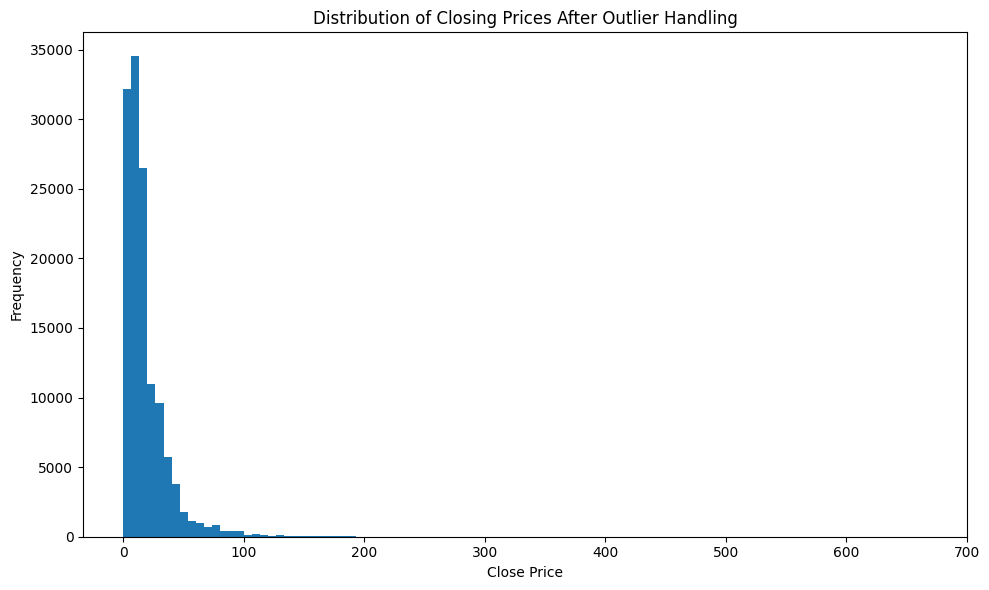

In [ ]:
# Distribution of closing prices after outlier handling

plt.figure(figsize=(10, 6))
plt.hist(final_data['close'].dropna(),bins=100)

plt.title('Distribution of Closing Prices After Outlier Handling')
plt.xlabel('Close Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


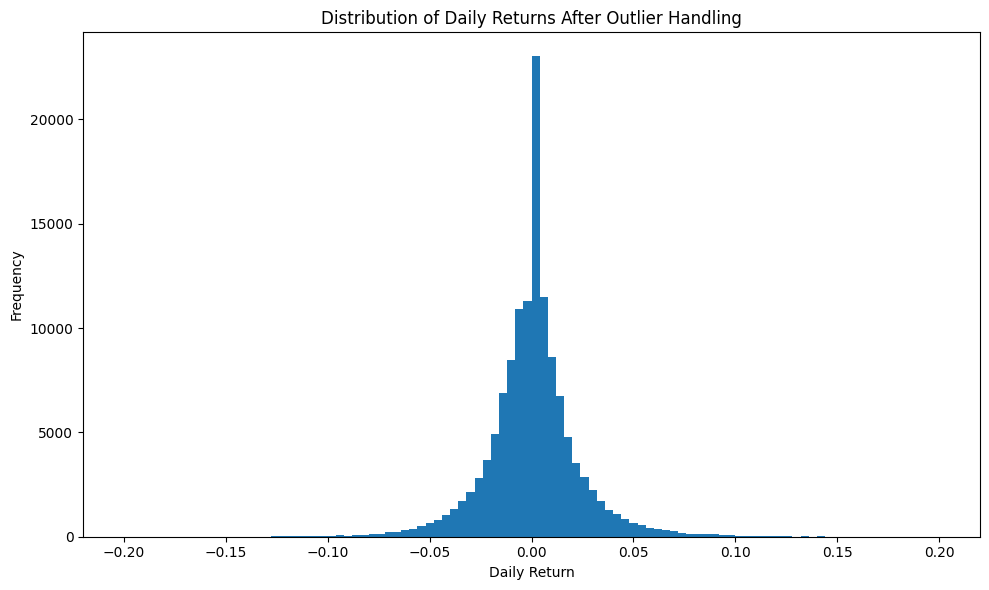

In [ ]:
# Distribution of daily returns after outlier handling

plt.figure(figsize=(10, 6))

plt.hist(
    final_data['daily_return'].dropna(),
    bins=100,range=(-0.20, 0.20))

plt.title('Distribution of Daily Returns After Outlier Handling')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
# Saving the current final prepared dataset

output_file = '/content/stock_prepared.csv'

final_data.to_csv(output_file,index=False)

print('Prepared dataset saved to:', output_file)
print('Saved dataset shape:', final_data.shape)


Prepared dataset saved to: /content/stock_prepared.csv
Saved dataset shape: (131111, 29)


In [ ]:
# Confirming the saved file

check_data = pd.read_csv(output_file)

print('Saved dataset shape:', check_data.shape)
print('Saved dataset duplicate ticker + date records:',
      check_data.duplicated(subset=['ticker', 'date']).sum())
print('Saved dataset missing values:',
      check_data.isnull().sum().sum())


Saved dataset shape: (131111, 29)
Saved dataset duplicate ticker + date records: 0
Saved dataset missing values: 0


# Part 5 — Documentation and Findings

## 1. What data-quality issues did you investigate?

I investigated missing values, duplicate records, duplicate ticker-date combinations, date formatting, the accidental `Symbol` record, and unusual close-price, volume, and daily-return observations.

## 2. What decisions did you make about unusual observations?

I used a conservative 3 × IQR rule within each ticker to identify unusual close prices, trading volumes, and extreme daily returns. Observations meeting the defined outlier criteria were removed because they could distort daily returns and volatility. After cleaning, returns were calculated only when a valid previous observation remained, so artificial returns were not created across removed records.

## 3. What new features did you create?

I created **price_change**, **daily_return**, **close_lag_1**, **ma_5**, **ma_20**, **volatility_20**, and **high_low_range**.

## 4. Which feature may be useful for future analysis, and why?

Daily return may be useful because it measures percentage price movement and allows price changes to be compared across stocks with different price levels.

## 5. What does the final prepared dataset contain?

The final dataset contains stock identifiers, dates, price and volume variables, engineered price-movement features, volatility and trading-range information, industry metadata, and one-hot encoded exchange and sector variables.

## 6. What additional information or features might be useful when building a predictive model?

Adding useful information could include market indexes, company financial indicators, trading-volume trends, sector performance, and other technical indicators.


Colab Link

https://colab.research.google.com/drive/1LoNSJQh-iOIt0RJATqtUHhqIBZMCZ_-S?usp=sharing